In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
#=========================================#
#      Etapa 1 - Parâmetros da Célula     #
#=========================================#

I_sc = 3.15                                                # Corrente de curto-circuito [A]
V_oc = 0.59                                                # Tensão de circuito aberto [V]
V_max = 0.48                                               # Tensão de máxima potência [V]
I_max = 2.91                                               # Corrente de máxima potência [A]
Area = 0.01                                                # Área da célula [m^2]
W = 1000                                                   # Irradiação STC [W/m^2]

#=========================================#
#          Constantes Físicas             #
#=========================================#

k = 1.38e-23                                               # Constante de Boltzmann 
q = 1.6e-19                                                # Carga do eletrão 
T_celsius = 25                                             # Temperatura STC
T = T_celsius + 273.15                                     # Temperatura em Kelvin 

In [44]:
#=========================================#
#      Etapa 2 - Cálculos Iniciais        #
#=========================================#

V_T = (k * T) / q                                           # Potencial térmico
m = (V_max - V_oc) / (V_T * np.log(1 - (I_max / I_sc)))     # Cálculo do fator de idealidade 'm' 
I0 = I_sc / (np.exp(V_oc / (m * V_T)) - 1)                  # Corrente de saturação inversa I0 

#=========================================#
#   Etapa 2a - Resultados dos cálculos    #
#=========================================#
print(f"Potencial Térmico (V_T): {V_T:.4f} V")
print(f"Fator de Idealidade (m): {m:.4f}")
print(f"Corrente I0: {I0:.4e} A")

Potencial Térmico (V_T): 0.0257 V
Fator de Idealidade (m): 1.6615
Corrente I0: 3.1713e-06 A


In [ ]:
#=========================================#
#       Etapa 3 - Gerar a Curva I-V       #
#=========================================#

V_vec = np.linspace(0, V_oc, 100)                          # Variável V de 0 até Voc 
I_vec = I_sc - I0 * (np.exp(V_vec / (m * V_T)) - 1)        # Equação do modelo simplificado
P_vec = V_vec * I_vec                                      # Potência P = V * I 

In [ ]:
#=========================================#
#  Etapa 4 - Resultados de Performance    #
#=========================================#

P_max_calc = np.max(P_vec)  
FF = P_max_calc / (V_oc * I_sc)                            # Fator de Forma
n_max = P_max_calc / (Area * W)                            # Rendimento

#=========================================#
#      Etapa 4a - Resultado Output        #
#=========================================#

print(f"Fator de Forma (FF): {FF:.4f}")
print(f"Rendimento Máximo: {n_max*100:.2f}%")

Fator de Forma (FF): 0.7517
Rendimento Máximo: 13.97%


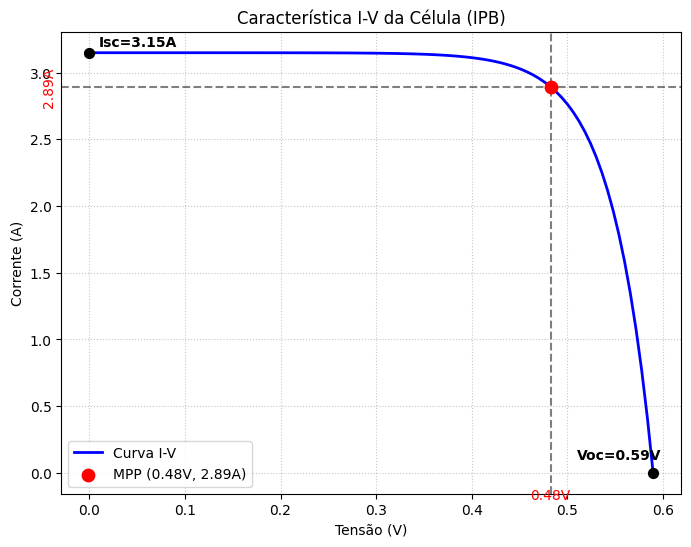

In [ ]:
#=========================================#
#        Etapa 5 - Gráfico I-V            #
#=========================================#
plt.figure(figsize=(8, 6))

#=========================================#
#             Curva principal             #
#=========================================#
plt.plot(V_vec, I_vec, 'b', linewidth=2, label='Curva I-V')

#=========================================#
#           Ponto MPP (O Joelho)          #
#=========================================#
idx_mpp = np.argmax(P_vec)
plt.scatter(V_vec[idx_mpp], I_vec[idx_mpp], color='red', s=80, zorder=5, 
            label=f'MPP ({V_vec[idx_mpp]:.2f}V, {I_vec[idx_mpp]:.2f}A)')

#=========================================#
#            Pontos Isc e Voc             #
#=========================================#
plt.scatter(0, I_sc, color='black', s=50, zorder=5)
plt.text(0.01, I_sc+0.05, f'Isc={I_sc}A', fontweight='bold')

plt.scatter(V_oc, 0, color='black', s=50, zorder=5)
plt.text(V_oc-0.08, 0.1, f'Voc={V_oc}V', fontweight='bold')

#=========================================#
#                 Estética                #
#=========================================#
plt.xlabel('Tensão (V)')
plt.ylabel('Corrente (A)')
plt.title('Característica I-V da Célula (IPB)')
plt.grid(True, linestyle=':', alpha=0.7)

#=========================================#
#   I - Linha Vertical (da Tensão Vmpp)   #
#=========================================#
plt.axvline(x=V_vec[idx_mpp], color='black', linestyle='--', alpha=0.5)

#=========================================#
# II. Linha Horizontal (da Corrente Impp) #
#=========================================#
plt.axhline(y=I_vec[idx_mpp], color='black', linestyle='--', alpha=0.5)
#=========================================================#
# 3.  Adicionar rótulos nos eixos para os valores exatos  #
#=========================================================#
plt.text(V_vec[idx_mpp], -0.2, f'{V_vec[idx_mpp]:.2f}V', color='red', ha='center')
plt.text(-0.05, I_vec[idx_mpp], f'{I_vec[idx_mpp]:.2f}A', color='red', va='center', rotation=90)

plt.legend()
plt.show()

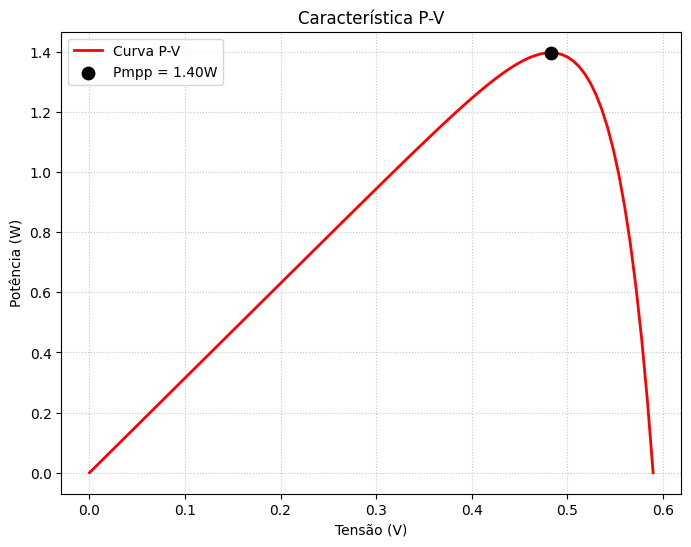

In [ ]:
#=========================================#
#        Etapa 6 - Gráfico P-V            #
#=========================================#
plt.figure(figsize=(8, 6))
plt.plot(V_vec, P_vec, 'r', linewidth=2, label='Curva P-V')

#=========================================#
#    I -  Ponto de Potência Máxima        #
#=========================================#
plt.scatter(V_vec[idx_mpp], P_max_calc, color='black', s=80, zorder=5, 
            label=f'Pmpp = {P_max_calc:.2f}W')

plt.xlabel('Tensão (V)')
plt.ylabel('Potência (W)')
plt.title('Característica P-V')
plt.grid(True, linestyle=':', alpha=0.7)


plt.legend()
plt.show()

In [ ]:

#=========================================#
#      Etapa 7 - Parâmetros Modelo Real   #
#=========================================#
                                                    # Valores típicos para uma célula de silício (podes ajustar se o professor deu outros)
R_s = 0.005                                         # Resistência série [Ohms] - deve ser pequena
R_p = 100                                           # Resistência paralelo [Ohms] - deve ser grande

                                                    # A corrente fotogerada Iph no modelo real é aproximadamente Isc
I_ph = I_sc 

                                                    # Função que define a equação real: f(I) = 0
def equacao_real(I, V, I_ph, I0, m, V_T, R_s, R_p):
                                                    # I = Iph - Id - Ip
    termo_exponencial = I0 * (np.exp((V + I * R_s) / (m * V_T)) - 1)
    termo_paralelo = (V + I * R_s) / R_p
    return I_ph - termo_exponencial - termo_paralelo - I

print("Modelo Real configurado. Pronto para resolver as equações!")

Modelo Real configurado. Pronto para resolver as equações!


In [45]:
#=========================================#
#      Etapa 8 - Resolver Modelo Real     #
#=========================================#
I_vec_real = np.zeros(len(V_vec))

#=========================================#
#  Resolvemos para cada V no vetor V_vec  #
#=========================================#
for i in range(len(V_vec)):
                                                    # O fsolve tenta encontrar o I que zera a função definida acima
                                                    # Usamos o I_vec da Parte I como "chute inicial" (guess)
    I_vec_real[i] = fsolve(equacao_real, I_vec[i], args=(V_vec[i], I_ph, I0, m, V_T, R_s, R_p))[0]

P_vec_real = V_vec * I_vec_real

#=========================================#
#        Performance do Modelo Real       #
#=========================================#
P_max_real = np.max(P_vec_real)
idx_mpp_real = np.argmax(P_vec_real)
FF_real = P_max_real / (V_oc * I_sc)
n_max_real = P_max_real / (Area * W)

print(f"--- Resultados Modelo Real ---")
print(f"FF Real: {FF_real:.4f} (Ideal era {FF:.4f})")
print(f"Rendimento Real: {n_max_real*100:.2f}% (Ideal era {n_max*100:.2f}%)")

--- Resultados Modelo Real ---
FF Real: 0.7281 (Ideal era 0.7517)
Rendimento Real: 13.53% (Ideal era 13.97%)


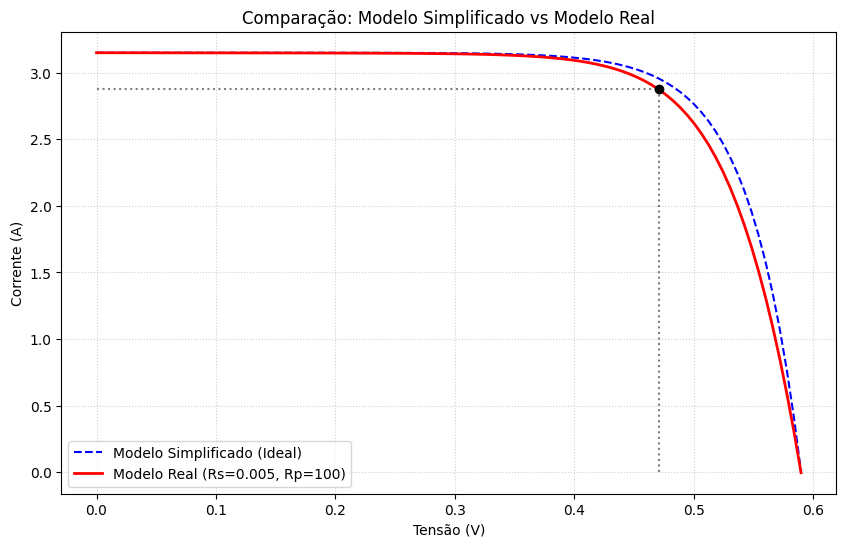

In [42]:
#=========================================#
#      Etapa 9 - Gráfico Comparativo      #
#=========================================#
plt.figure(figsize=(10, 6))

#=========================================#
#      Modelo Simplificado (Parte I)      #
#=========================================#
plt.plot(V_vec, I_vec, '--b', label='Modelo Simplificado (Ideal)')

#=========================================#
#        Modelo Real (Parte II)           #
#=========================================#
plt.plot(V_vec, I_vec_real, 'r', linewidth=2, label=f'Modelo Real (Rs={R_s}, Rp={R_p})')

#=========================================#
#           Marcando os joelhos           #
#=========================================#
plt.scatter(V_vec[idx_mpp_real], I_vec_real[idx_mpp_real], color='black', zorder=5)

#=========================================#
#      Linhas de guia para o novo MPP     #
#=========================================#
plt.vlines(V_vec[idx_mpp_real], 0, I_vec_real[idx_mpp_real], colors='black', linestyles='dotted', alpha=0.5)
plt.hlines(I_vec_real[idx_mpp_real], 0, V_vec[idx_mpp_real], colors='black', linestyles='dotted', alpha=0.5)

plt.xlabel('Tensão (V)')
plt.ylabel('Corrente (A)')
plt.title('Comparação: Modelo Simplificado vs Modelo Real')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [82]:
from IPython.display import display, Markdown

#=========================================#
#      Etapa 10 - Memorial Detalhado      #
#=========================================#


# Cálculos auxiliares para mostrar no passo a passo
ln_termo = np.log(1 - I_max/I_sc)
exp_valor = V_oc / (m * V_T)

memorial_passo_a_passo = f"""
# Relatório de Caracterização Fotovoltaica

Este memorial de cálculo serve para documentar a modelação matemática e a simulação de uma célula solar de silício, comparando o seu comportamento ideal com o comportamento real sob condições padrão de teste (STC). O objetivo é quantificar como as perdas internas impactam a eficiência energética do dispositivo.

---

## 1. Parâmetros de Entrada (STC)
Os cálculos iniciais baseiam-se nos dados nominais fornecidos:
* **Isc:** {I_sc} A (Corrente de Curto-Circuito)
* **Voc:** {V_oc} V (Tensão de Circuito Aberto)
* **Pmpp (Especificada):** {V_max * I_max:.2f} W (Potência Máxima Nominal)

---

## 2. Desenvolvimento do Modelo 

Nesta **Etapa 2**, o foco é a transição da teoria para a simulação real. Enquanto na Etapa 1 assumimos uma célula perfeita, aqui introduzimos o **Modelo de um Díodo com Perdas**, onde:
1. **Fator de Idealidade (m):** Ajusta a curva exponencial do díodo à realidade física da junção P-N.
2. **Resistências Parasitas ($R_s$ e $R_p$):** Representam as perdas por condução nos contactos metálicos e as fugas de corrente pelas bordas da célula.

Abaixo seguem os cálculos detalhados:

$$V_T = \\frac{{k \\cdot T}}{{q}}$$
$$V_T = \\frac{{{k:.2e} \\cdot {T:.2f}}}{{{q:.2e}}}$$
**$V_T = {V_T:.4f}$ V**

---

## 3. Fator de Idealidade ($m$)
Nesta fase, ajustamos a física do díodo aos dados experimentais. 

$$m = \\frac{{V_{{max}} - V_{{oc}}}}{{V_T \\cdot \\ln(1 - \\frac{{I_{{max}}}}{{I_{{sc}}}})}}$$
$$m = \\frac{{{V_max} - {V_oc}}}{{{V_T:.4f} \\cdot \\ln(1 - \\frac{{{I_max}}}{{{I_sc}}})}}$$
$$m = \\frac{{{-0.11:.2f}}}{{{V_T:.4f} \\cdot ({ln_termo:.4f})}}$$

* **Fator de Idealidade ($m$):** Este parâmetro, calculado como **$m$ ={m:.4f}**, representa as perdas por recombinação na junção P-N. Valores acima de 1 indicam que a célula se desvia do modelo ideal de difusão, sendo essencial para ajustar o "joelho" da curva I-V.


---

## 4. Corrente de Saturação Inversa ($I_0$)
Nesta fase, ajustamos a física do díodo aos dados experimentais para definir o comportamento intrínseco da célula.
$$I_0 = \\frac{{I_{{sc}}}}{{e^{{\\frac{{V_{{oc}}}}{{m \\cdot V_T}}}} - 1}}$$
$$I_0 = \\frac{{{I_sc}}}{{e^{{\\frac{{{V_oc}}}{{{m:.4f} \\cdot {V_T:.4f}}}}} - 1}}$$
$$I_0 = \\frac{{{I_sc}}}{{{np.exp(exp_valor):.2f} - 1}}$$
**$I_0 = {I0:.4e}$ A**

---

## 5. Fator de Forma ($FF$) e Rendimento Máximo ($\\eta_{{max}}$)
 
* **Fator de Forma ($FF$)**
O Fator de Forma para o modelo ideal é calculado com base na potência máxima teórica:
$$FF = \\frac{{P_{{max}}}}{{V_{{oc}} \\cdot I_{{sc}}}}$$
$$FF = \\frac{{{P_max_calc:.4f}}}{{{V_oc} \\cdot {I_sc}}}$$
**$FF = {FF:.4f}$**

* **Rendimento Máximo ($\\eta_{{max}}$)**
O rendimento ideal mostra a capacidade máxima de conversão da célula nas condições STC:
$$\\eta_{{max}} = \\frac{{P_{{max}}}}{{Area \\cdot W}}$$
$$\\eta_{{max}} = \\frac{{{P_max_calc:.4f}}}{{{Area} \\cdot {W}}}$$
$$\\eta_{{max}} = {n_max:.4f}$$
**$\\eta_{{max}} = {n_max*100:.2f}\\%$**

**Nota:** Estes valores representam o limite teórico da célula antes de aplicarmos o modelo real na Etapa 2.*

---


## 6. Memorial do Modelo Real (Com $R_s$ e $R_p$)

Na segunda etapa, abandonamos o modelo ideal e inserimos as perdas físicas da célula. A corrente $I$ agora depende da queda de tensão na resistência série e da fuga na resistência paralelo.

### Parâmetros de Perda Adotados:
* **Resistência Série ($R_s$):** {R_s} $\\Omega$
* **Resistência Paralelo ($R_p$):** {R_p} $\\Omega$

### Equação de Balanço de Correntes:
A corrente de saída é dada por:
$$I = I_{{PH}} - I_D - I_P$$

Substituindo as expressões do modelo real:
$$I = I_{{PH}} - I_0 \\cdot \\left[ e^{{\\frac{{V + R_s \\cdot I}}{{m \\cdot V_T}}}} - 1 \\right] - \\frac{{V + R_s \\cdot I}}{{R_p}}$$

### Demonstração com Valores Substituídos:
Para cada ponto da curva, o sistema resolveu:
$$I = {I_sc} - ({I0:.4e}) \\cdot \\left[ e^{{\\frac{{V + {R_s} \\cdot I}}{{{m:.4f} \\cdot {V_T:.4f}}}}} - 1 \\right] - \\frac{{V + {R_s} \\cdot I}}{{{R_p}}}$$

---

## 7. Resultados Finais (Modelo Real)
Nesta etapa, introduzimos as perdas físicas. A corrente é obtida numericamente via `fsolve`:
Considerando $R_s = {R_s}\\Omega$ e $R_p = {R_p}\\Omega$:

* **Fator de Forma (FF):**
$$FF = \\frac{{P_{{max}}}}{{V_{{oc}} \\cdot I_{{sc}}}} = \\frac{{{P_max_real:.4f}}}{{{V_oc} \\cdot {I_sc}}} = {FF_real:.4f}$$

* **Rendimento ($\eta$):**
$$\\eta = \\frac{{P_{{max}}}}{{Area \\cdot W}} = \\frac{{{P_max_real:.4f}}}{{{Area} \\cdot {W}}} = {n_max_real*100:.2f}\\%$$

---

## 8. Impacto nos Resultados Finais
A tabela abaixo resume o impacto das resistências internas no Ponto de Máxima Potência (MPP):
| Parâmetro | Valor no Modelo Real | Diferença vs Ideal |
| :--- | :---: | :---: |
| **Pmax** | {P_max_real:.3f} W | {P_max_real - P_max_calc:.3f} W |
| **Vem mpp** | {V_vec[idx_mpp_real]:.3f} V | {V_vec[idx_mpp_real] - V_vec[idx_mpp]:.3f} V |
| **Iem mpp** | {I_vec_real[idx_mpp_real]:.3f} A | {I_vec_real[idx_mpp_real] - I_vec[idx_mpp]:.3f} A |

**Nota técnica:** A inclusão de $R_s$ causou uma queda na tensão disponível no ponto de máxima potência, enquanto $R_p$ reduziu ligeiramente a corrente disponível ao longo de toda a curva.

---

## 9. Resultados Obtidos

Nesta etapa final de processamento, consolidamos os dados extraídos das curvas de potência. A tabela abaixo apresenta a comparação quantitativa entre o cenário teórico e o cenário de operação real da célula.

| Grandeza | Modelo Simplificado (Ideal) | Modelo Real (Rs={R_s}Ω, Rp={R_p}Ω) |
| :--- | :---: | :---: |
| **Potência Máxima (Pmax)** | {P_max_calc:.4f} W | {P_max_real:.4f} W |
| **Tensão no MPP (Vmpp)** | {V_vec[idx_mpp]:.4f} V | {V_vec[idx_mpp_real]:.4f} V |
| **Corrente no MPP (Impp)** | {I_vec[idx_mpp]:.4f} A | {I_vec_real[idx_mpp_real]:.4f} A |
| **Fator de Forma (FF)** | {FF:.4f} | {FF_real:.4f} |
| **Rendimento ($\eta$)** | {n_max*100:.2f}% | {n_max_real*100:.2f}% |
---
## Etapa 10: Conclusão Geral
A análise demonstra que as imperfeições físicas degradam significativamente o desempenho da célula. A resistência série ($R_s$) é a principal responsável pela queda de tensão no MPP, enquanto a resistência paralelo ($R_p$) introduz fugas de corrente. A redução observada no **Fator de Forma (FF)** e no **Rendimento ($\eta$)** comprova que o modelo real é indispensável para previsões precisas em Engenharia Eletrotécnica.

"""

display(Markdown(memorial_passo_a_passo))

<>:142: SyntaxWarning: invalid escape sequence '\e'
<>:142: SyntaxWarning: invalid escape sequence '\e'
<>:142: SyntaxWarning: invalid escape sequence '\e'
<>:142: SyntaxWarning: invalid escape sequence '\e'
<>:142: SyntaxWarning: invalid escape sequence '\e'
<>:142: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Don\AppData\Local\Temp\ipykernel_19564\2990931208.py:142: SyntaxWarning: invalid escape sequence '\e'
  """
C:\Users\Don\AppData\Local\Temp\ipykernel_19564\2990931208.py:142: SyntaxWarning: invalid escape sequence '\e'
  """
C:\Users\Don\AppData\Local\Temp\ipykernel_19564\2990931208.py:142: SyntaxWarning: invalid escape sequence '\e'
  """



# Relatório de Caracterização Fotovoltaica

Este memorial de cálculo serve para documentar a modelação matemática e a simulação de uma célula solar de silício, comparando o seu comportamento ideal com o comportamento real sob condições padrão de teste (STC). O objetivo é quantificar como as perdas internas impactam a eficiência energética do dispositivo.

---

## 1. Parâmetros de Entrada (STC)
Os cálculos iniciais baseiam-se nos dados nominais fornecidos:
* **Isc:** 3.15 A (Corrente de Curto-Circuito)
* **Voc:** 0.59 V (Tensão de Circuito Aberto)
* **Pmpp (Especificada):** 1.40 W (Potência Máxima Nominal)

---

## 2. Desenvolvimento do Modelo 

Nesta **Etapa 2**, o foco é a transição da teoria para a simulação real. Enquanto na Etapa 1 assumimos uma célula perfeita, aqui introduzimos o **Modelo de um Díodo com Perdas**, onde:
1. **Fator de Idealidade (m):** Ajusta a curva exponencial do díodo à realidade física da junção P-N.
2. **Resistências Parasitas ($R_s$ e $R_p$):** Representam as perdas por condução nos contactos metálicos e as fugas de corrente pelas bordas da célula.

Abaixo seguem os cálculos detalhados:

$$V_T = \frac{k \cdot T}{q}$$
$$V_T = \frac{1.38e-23 \cdot 298.15}{1.60e-19}$$
**$V_T = 0.0257$ V**

---

## 3. Fator de Idealidade ($m$)
Nesta fase, ajustamos a física do díodo aos dados experimentais. 

$$m = \frac{V_{max} - V_{oc}}{V_T \cdot \ln(1 - \frac{I_{max}}{I_{sc}})}$$
$$m = \frac{0.48 - 0.59}{0.0257 \cdot \ln(1 - \frac{2.91}{3.15})}$$
$$m = \frac{-0.11}{0.0257 \cdot (-2.5745)}$$

* **Fator de Idealidade ($m$):** Este parâmetro, calculado como **$m$ =1.6615**, representa as perdas por recombinação na junção P-N. Valores acima de 1 indicam que a célula se desvia do modelo ideal de difusão, sendo essencial para ajustar o "joelho" da curva I-V.


---

## 4. Corrente de Saturação Inversa ($I_0$)
Nesta fase, ajustamos a física do díodo aos dados experimentais para definir o comportamento intrínseco da célula.
$$I_0 = \frac{I_{sc}}{e^{\frac{V_{oc}}{m \cdot V_T}} - 1}$$
$$I_0 = \frac{3.15}{e^{\frac{0.59}{1.6615 \cdot 0.0257}} - 1}$$
$$I_0 = \frac{3.15}{993294.72 - 1}$$
**$I_0 = 3.1713e-06$ A**

---

## 5. Fator de Forma ($FF$) e Rendimento Máximo ($\eta_{max}$)

* **Fator de Forma ($FF$)**
O Fator de Forma para o modelo ideal é calculado com base na potência máxima teórica:
$$FF = \frac{P_{max}}{V_{oc} \cdot I_{sc}}$$
$$FF = \frac{1.3971}{0.59 \cdot 3.15}$$
**$FF = 0.7517$**

* **Rendimento Máximo ($\eta_{max}$)**
O rendimento ideal mostra a capacidade máxima de conversão da célula nas condições STC:
$$\eta_{max} = \frac{P_{max}}{Area \cdot W}$$
$$\eta_{max} = \frac{1.3971}{0.01 \cdot 1000}$$
$$\eta_{max} = 0.1397$$
**$\eta_{max} = 13.97\%$**

**Nota:** Estes valores representam o limite teórico da célula antes de aplicarmos o modelo real na Etapa 2.*

---


## 6. Memorial do Modelo Real (Com $R_s$ e $R_p$)

Na segunda etapa, abandonamos o modelo ideal e inserimos as perdas físicas da célula. A corrente $I$ agora depende da queda de tensão na resistência série e da fuga na resistência paralelo.

### Parâmetros de Perda Adotados:
* **Resistência Série ($R_s$):** 0.005 $\Omega$
* **Resistência Paralelo ($R_p$):** 100 $\Omega$

### Equação de Balanço de Correntes:
A corrente de saída é dada por:
$$I = I_{PH} - I_D - I_P$$

Substituindo as expressões do modelo real:
$$I = I_{PH} - I_0 \cdot \left[ e^{\frac{V + R_s \cdot I}{m \cdot V_T}} - 1 \right] - \frac{V + R_s \cdot I}{R_p}$$

### Demonstração com Valores Substituídos:
Para cada ponto da curva, o sistema resolveu:
$$I = 3.15 - (3.1713e-06) \cdot \left[ e^{\frac{V + 0.005 \cdot I}{1.6615 \cdot 0.0257}} - 1 \right] - \frac{V + 0.005 \cdot I}{100}$$

---

## 7. Resultados Finais (Modelo Real)
Nesta etapa, introduzimos as perdas físicas. A corrente é obtida numericamente via `fsolve`:
Considerando $R_s = 0.005\Omega$ e $R_p = 100\Omega$:

* **Fator de Forma (FF):**
$$FF = \frac{P_{max}}{V_{oc} \cdot I_{sc}} = \frac{1.3532}{0.59 \cdot 3.15} = 0.7281$$

* **Rendimento ($\eta$):**
$$\eta = \frac{P_{max}}{Area \cdot W} = \frac{1.3532}{0.01 \cdot 1000} = 13.53\%$$

---

## 8. Impacto nos Resultados Finais
A tabela abaixo resume o impacto das resistências internas no Ponto de Máxima Potência (MPP):
| Parâmetro | Valor no Modelo Real | Diferença vs Ideal |
| :--- | :---: | :---: |
| **Pmax** | 1.353 W | -0.044 W |
| **Vem mpp** | 0.471 V | -0.012 V |
| **Iem mpp** | 2.874 A | -0.020 A |

**Nota técnica:** A inclusão de $R_s$ causou uma queda na tensão disponível no ponto de máxima potência, enquanto $R_p$ reduziu ligeiramente a corrente disponível ao longo de toda a curva.

---

## 9. Resultados Obtidos

Nesta etapa final de processamento, consolidamos os dados extraídos das curvas de potência. A tabela abaixo apresenta a comparação quantitativa entre o cenário teórico e o cenário de operação real da célula.

| Grandeza | Modelo Simplificado (Ideal) | Modelo Real (Rs=0.005Ω, Rp=100Ω) |
| :--- | :---: | :---: |
| **Potência Máxima (Pmax)** | 1.3971 W | 1.3532 W |
| **Tensão no MPP (Vmpp)** | 0.4827 V | 0.4708 V |
| **Corrente no MPP (Impp)** | 2.8942 A | 2.8742 A |
| **Fator de Forma (FF)** | 0.7517 | 0.7281 |
| **Rendimento ($\eta$)** | 13.97% | 13.53% |
---
## Etapa 10: Conclusão Geral
A análise demonstra que as imperfeições físicas degradam significativamente o desempenho da célula. A resistência série ($R_s$) é a principal responsável pela queda de tensão no MPP, enquanto a resistência paralelo ($R_p$) introduz fugas de corrente. A redução observada no **Fator de Forma (FF)** e no **Rendimento ($\eta$)** comprova que o modelo real é indispensável para previsões precisas em Engenharia Eletrotécnica.

